In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("all-state-changes.csv")
df

,state,timestamp,leading_candidate_name,trailing_candidate_name,leading_candidate_votes,trailing_candidate_votes,vote_differential,votes_remaining,new_votes,new_votes_relevant,new_votes_formatted,leading_candidate_partition,trailing_candidate_partition,precincts_reporting,precincts_total,hurdle,hurdle_change,hurdle_mov_avg,counties_partition,total_votes_count
0,Alaska (EV: 3),2020-12-02 19:04:28.768000,Trump,Biden,189951,153778,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530
1,Alaska (EV: 3),2020-12-02 17:18:21.996000,Trump,Biden,189951,153778,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530
2,Alaska (EV: 3),2020-12-02 16:33:22.842000,Trump,Biden,189951,153778,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530
3,Alaska (EV: 3),2020-12-02 15:22:19.152000,Trump,Biden,189951,153778,36173,31816,2304,587,587,0.226576,0.773424,441,441,1.094604,0.035231,0.494467,"{'ED 10': 51, 'ED 37': 102, 'ED 39': 119, 'ED ...",359530
4,Alaska (EV: 3),2020-12-01 18:45:19.099000,Trump,Biden,189818,153324,36494,34120,58,0,0,0.000000,0.000000,424,441,1.059373,0.000949,0.488333,{'ED 6': 58},357226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3401,Wyoming (EV: 3),2020-11-11 22:19:53.904000,Trump,Biden,193559,73491,120068,0,0,0,0,0.000000,0.000000,483,483,0.000000,0.000000,0.154079,{},276765
3402,Wyoming (EV: 3),2020-11-11 21:14:13.744000,Trump,Biden,193559,73491,120068,0,84,0,0,0.000000,0.000000,444,483,0.000000,-741.190169,0.154079,"{'Laramie': 1, 'Sweetwater': 83}",276765
3403,Wyoming (EV: 3),2020-11-11 20:39:54.585000,Trump,Biden,193559,73491,120068,84,153,151,151,0.695364,0.304636,444,483,741.190169,478.296072,0.154079,"{'Albany': 5, 'Campbell': 2, 'Carbon': 2, 'Con...",276681
3404,Wyoming (EV: 3),2020-11-06 02:50:08.240000,Trump,Biden,193454,73445,120009,237,185,180,180,0.972222,0.027778,444,483,262.894097,115.239337,0.027778,{'Niobrara': 185},276528


In [5]:
df['rep_votes'] = np.where(
    df['leading_candidate_name'] == 'Trump', 
    df['leading_candidate_votes'], 
    df['trailing_candidate_votes']
)

df['dem_votes'] = np.where(
    df['leading_candidate_name'] == 'Biden', 
    df['leading_candidate_votes'], 
    df['trailing_candidate_votes']
)

df = df.drop(columns=[
    'leading_candidate_name', 
    'trailing_candidate_name', 
    'leading_candidate_votes', 
    'trailing_candidate_votes'
])

df

,state,timestamp,vote_differential,votes_remaining,new_votes,new_votes_relevant,new_votes_formatted,leading_candidate_partition,trailing_candidate_partition,precincts_reporting,precincts_total,hurdle,hurdle_change,hurdle_mov_avg,counties_partition,total_votes_count,rep_votes,dem_votes
0,Alaska (EV: 3),2020-12-02 19:04:28.768000,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530,189951,153778
1,Alaska (EV: 3),2020-12-02 17:18:21.996000,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530,189951,153778
2,Alaska (EV: 3),2020-12-02 16:33:22.842000,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530,189951,153778
3,Alaska (EV: 3),2020-12-02 15:22:19.152000,36173,31816,2304,587,587,0.226576,0.773424,441,441,1.094604,0.035231,0.494467,"{'ED 10': 51, 'ED 37': 102, 'ED 39': 119, 'ED ...",359530,189951,153778
4,Alaska (EV: 3),2020-12-01 18:45:19.099000,36494,34120,58,0,0,0.000000,0.000000,424,441,1.059373,0.000949,0.488333,{'ED 6': 58},357226,189818,153324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3401,Wyoming (EV: 3),2020-11-11 22:19:53.904000,120068,0,0,0,0,0.000000,0.000000,483,483,0.000000,0.000000,0.154079,{},276765,193559,73491
3402,Wyoming (EV: 3),2020-11-11 21:14:13.744000,120068,0,84,0,0,0.000000,0.000000,444,483,0.000000,-741.190169,0.154079,"{'Laramie': 1, 'Sweetwater': 83}",276765,193559,73491
3403,Wyoming (EV: 3),2020-11-11 20:39:54.585000,120068,84,153,151,151,0.695364,0.304636,444,483,741.190169,478.296072,0.154079,"{'Albany': 5, 'Campbell': 2, 'Carbon': 2, 'Con...",276681,193559,73491
3404,Wyoming (EV: 3),2020-11-06 02:50:08.240000,120009,237,185,180,180,0.972222,0.027778,444,483,262.894097,115.239337,0.027778,{'Niobrara': 185},276528,193454,73445


We plot the current vote share for each swing state over time to see how vote totals change.

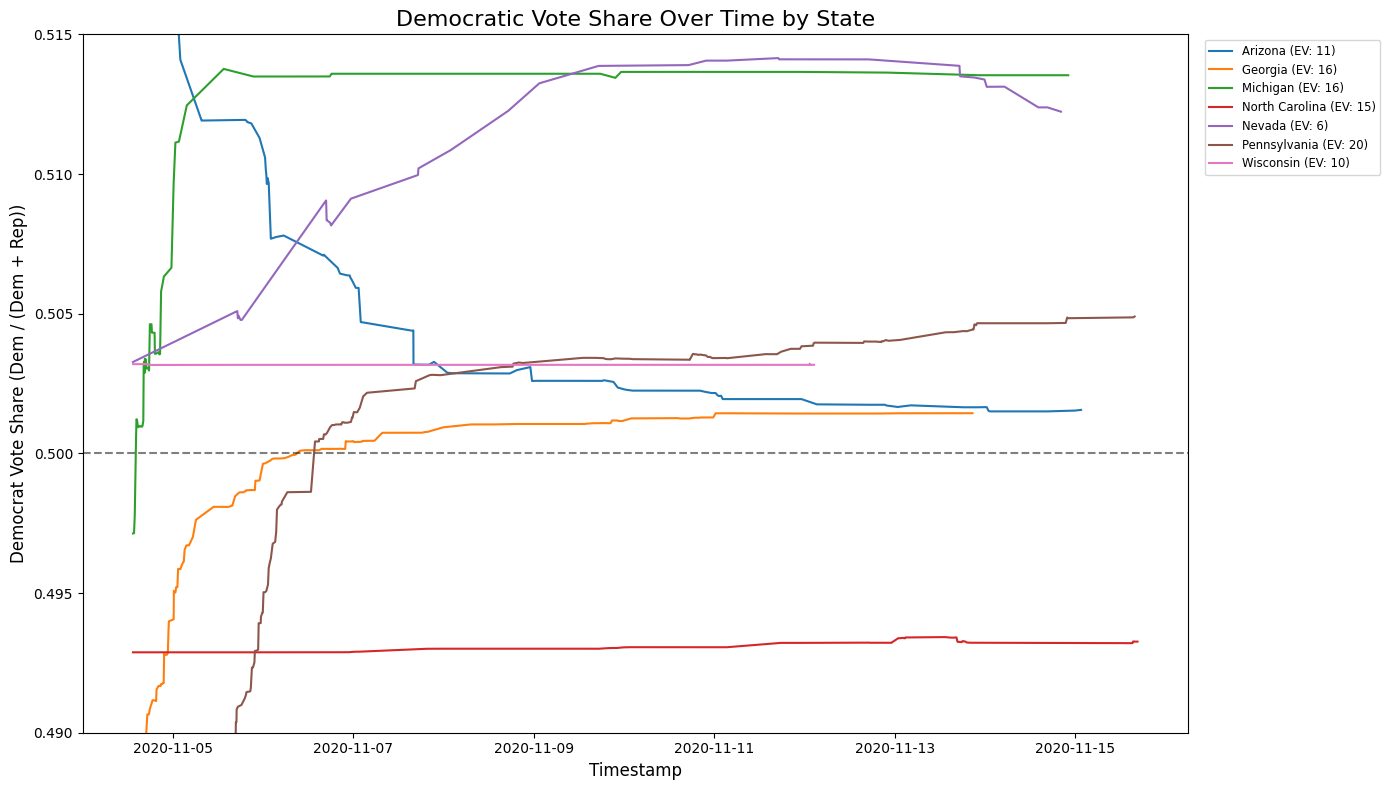

In [ ]:
# 1. Ensure the timestamp column is a datetime object so it plots correctly
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Calculate the Democratic vote share
# (Make sure you've already created dem_votes and rep_votes as shown previously)
df['dem_share'] = df['dem_votes'] / (df['dem_votes'] + df['rep_votes'])

# 3. Create the plot
plt.figure(figsize=(14, 8))


# Optional: Filter for just the swing states
swing_states = ['Pennsylvania (EV: 20)', 'Georgia (EV: 16)', 'Michigan (EV: 16)', 
                'Wisconsin (EV: 10)', 'Arizona (EV: 11)', 'Nevada (EV: 6)', 'North Carolina (EV: 15)']

swing_df = df[df['state'].isin(swing_states)]
swing_df_filtered = swing_df[swing_df['timestamp'] < '2020-11-16'].copy()


# Then plug `swing_df` into sns.lineplot instead of `df`
# sns.lineplot automatically groups by 'state' when you use the 'hue' parameter
sns.lineplot(data=swing_df_filtered, x='timestamp', y='dem_share', hue='state', linewidth=1.5)

# 4. Formatting the chart
plt.title('Democratic Vote Share Over Time by State', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Democrat Vote Share (Dem / (Dem + Rep))', fontsize=12)


plt.ylim(0.49, 0.515)
# Add a horizontal line at 0.5 (50%) to easily see who is winning the two-party vote
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

# Move the legend outside the plot area so it doesn't cover up the lines (since there are ~50 states)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

Now we plot how the vote totals change with respect to the total vote share in - probably a more meaningful metric, and allows us to check for linearity in vote share changes over the last votes to come in.

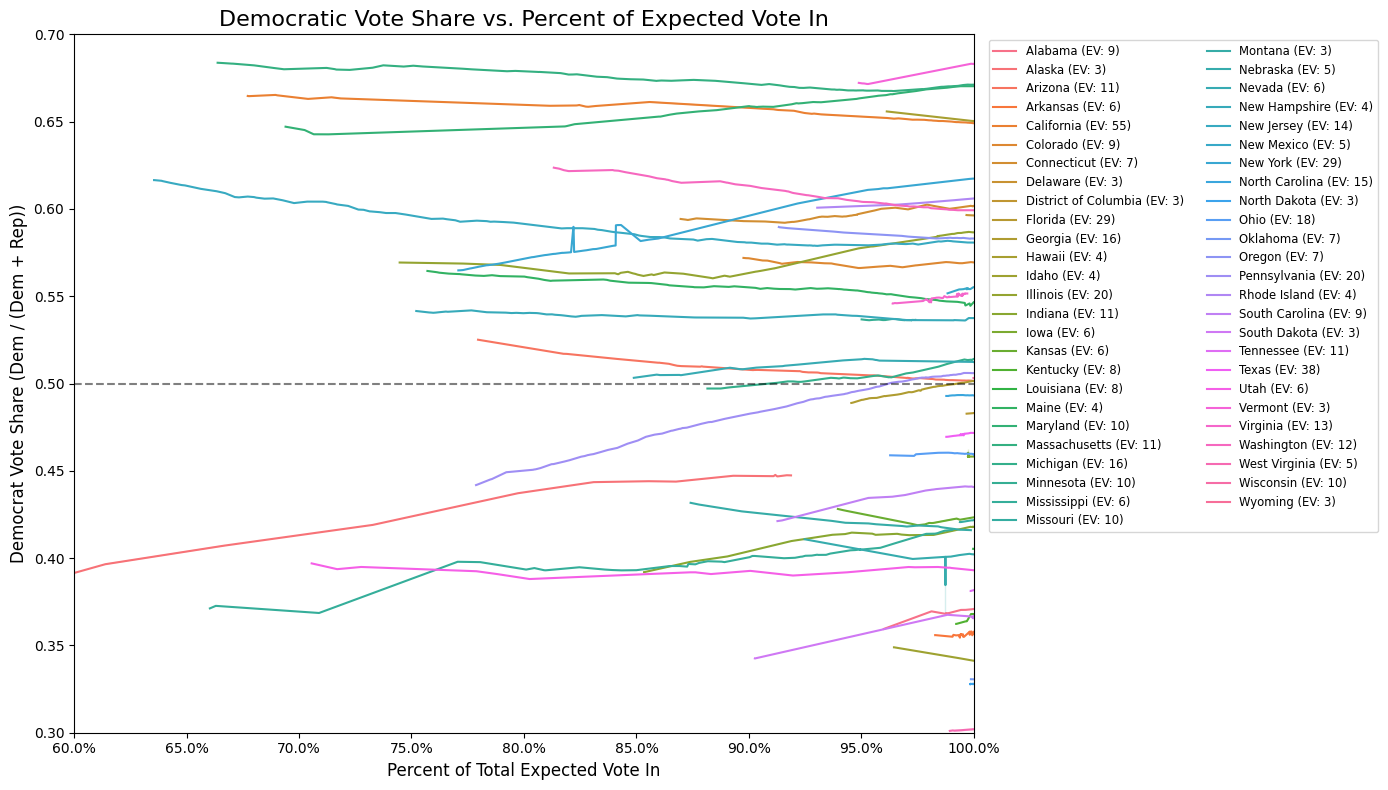

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. Ensure the timestamp column is a datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Filter the data to include only rows up to November 15, 2020

# 3. Calculate the Democratic vote share
df['dem_share'] = df['dem_votes'] / (df['dem_votes'] + df['rep_votes'])

# 4. Calculate the percent of expected vote in
# We find the percentage by dividing current votes by (current votes + remaining votes)
df['total_expected_votes'] = df['total_votes_count'] + df['votes_remaining']
df['percent_vote_in'] = df['total_votes_count'] / df['total_expected_votes']

swing_states = ['Pennsylvania (EV: 20)', 'Georgia (EV: 16)', 'Michigan (EV: 16)', 
                'Wisconsin (EV: 10)', 'Arizona (EV: 11)', 'Nevada (EV: 6)', 'North Carolina (EV: 15)']

swing_df = df[df['state'].isin(swing_states)]

# 5. Create the plot
plt.figure(figsize=(14, 8))

# Update x to 'percent_vote_in'
sns.lineplot(data=df, x='percent_vote_in', y='dem_share', hue='state', linewidth=1.5)

# 6. Formatting the chart
plt.title('Democratic Vote Share vs. Percent of Expected Vote In', fontsize=16)
plt.xlabel('Percent of Total Expected Vote In', fontsize=12)
plt.ylabel('Democrat Vote Share (Dem / (Dem + Rep))', fontsize=12)

# Set the y-axis limits to zoom in on the 0.48 to 0.52 range

# Set the x-axis limits from 0 to 1 (0% to 100%)
plt.xlim(0.6, 1.0)
plt.ylim(0.3, 0.7)

# Format the x-axis to show percentages (e.g., 90% instead of 0.9)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

# Add a horizontal line at 0.5 (50%)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2, fontsize='small')

plt.tight_layout()
plt.show()

We tentatively proposed a model where the first batch of votes is distinct from all following batches of votes. To check how reasonable this is, and to see what the model dynamics would be, we examine how each following vote batch differs from the first vote batch from that state.

In [30]:
# 1. Ensure timestamp is a datetime object and sort the data 
# Sorting is crucial so that the 'first' row for each state is actually the earliest time
df = df.sort_values(by=['state', 'timestamp'])

first_share_per_state = df.groupby('state')['dem_share'].transform('first')


df['dem_share_diff_from_first'] = df['dem_share'] - first_share_per_state

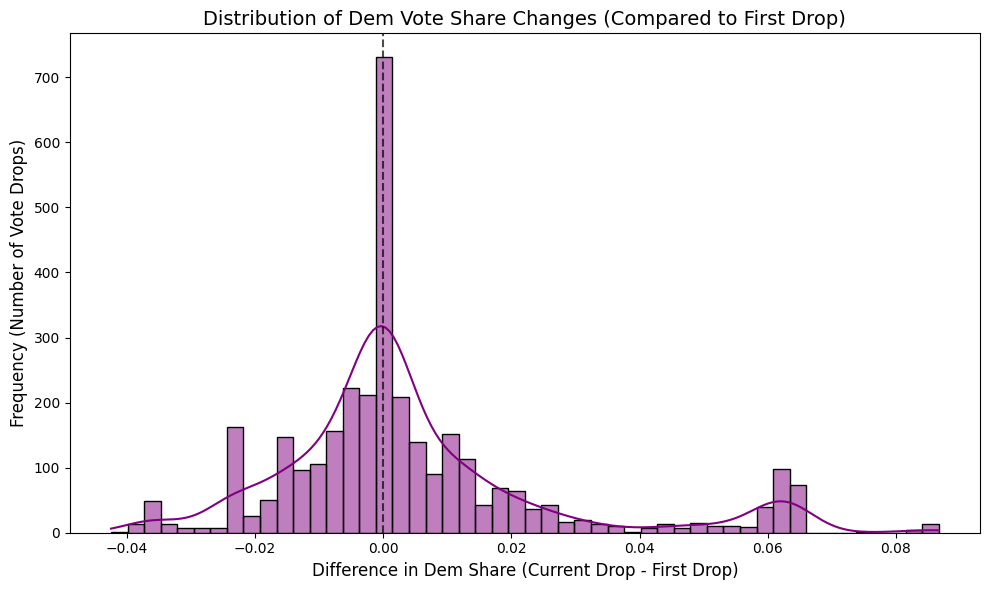

In [31]:
plt.figure(figsize=(10, 6))

# Filter out the first drops (which are exactly 0.0) so they don't skew the visual
plot_data = df[df['dem_share_diff_from_first'] != 0.0]

# Create the histogram
# bins=50 controls the number of bars, kde=True adds a smoothed trendline
sns.histplot(data=plot_data, x='dem_share_diff_from_first', bins=50, kde=True, color='purple')

# Formatting the chart
plt.title('Distribution of Dem Vote Share Changes (Compared to First Drop)', fontsize=14)
plt.xlabel('Difference in Dem Share (Current Drop - First Drop)', fontsize=12)
plt.ylabel('Frequency (Number of Vote Drops)', fontsize=12)

# Add a vertical line at 0 for easy reference (no change)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Now we check how these batch differences behave by state.

In [34]:
state_diff_stats = df.groupby('state')['dem_share_diff_from_first'].agg(['mean', 'std']).reset_index()

# 3. Rename the columns for clarity
state_diff_stats = state_diff_stats.rename(columns={
    'mean': 'mean_diff_from_first', 
    'std': 'std_diff_from_first'
})

# 4. Sort the values (optional: for example, by highest mean difference)
state_diff_stats = state_diff_stats.sort_values(by='mean_diff_from_first', ascending=False)

# Display the results
state_diff_stats

,state,mean_diff_from_first,std_diff_from_first
1,Alaska (EV: 3),0.066272,0.032393
38,Pennsylvania (EV: 20),0.052539,0.016147
24,Mississippi (EV: 6),0.029058,0.009427
14,Indiana (EV: 11),0.022474,0.006560
40,South Carolina (EV: 9),0.017665,0.004405
41,South Dakota (EV: 3),0.011111,0.011795
22,Michigan (EV: 16),0.010920,0.005748
10,Georgia (EV: 16),0.009989,0.003256
0,Alabama (EV: 9),0.009507,0.002938
20,Maryland (EV: 10),0.008024,0.009240


There are many states which have effectively no vote shift between future batches - most likely these are states that mostly report everything in the first batch. Among states with reasonably large mean batch effect though, it seems that generally the mean is at least 2 standard deviations away from 0, suggesting that the states do have meaningful individual batch effects. 

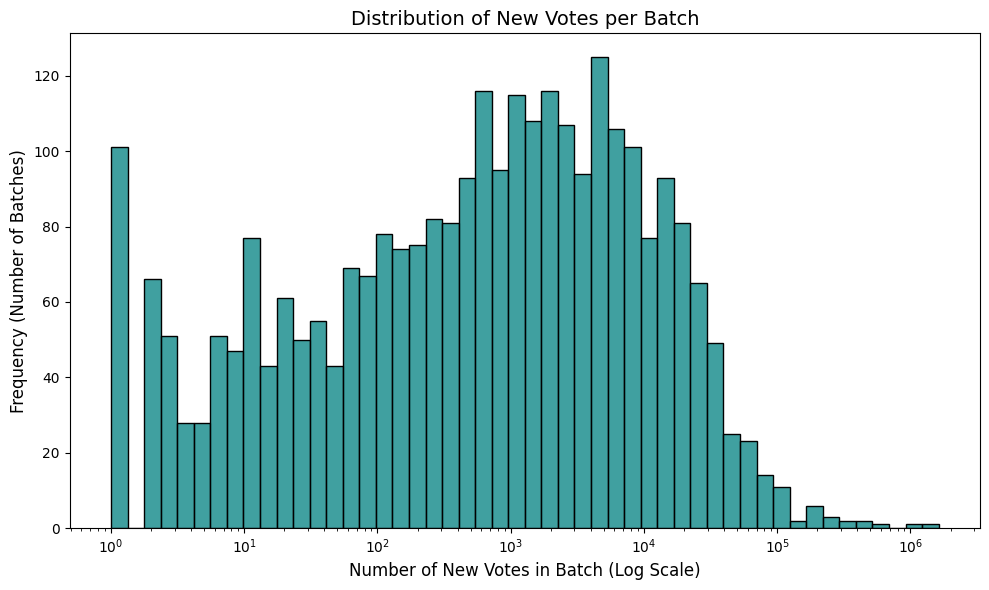

In [36]:
plt.figure(figsize=(10, 6))

# We use log_scale=True for the x-axis because vote batch sizes 
# can range from single digits to hundreds of thousands.
sns.histplot(data=df, x='new_votes', bins=50, color='teal', log_scale=(True, False))

# Formatting the chart
plt.title('Distribution of New Votes per Batch', fontsize=14)
plt.xlabel('Number of New Votes in Batch (Log Scale)', fontsize=12)
plt.ylabel('Frequency (Number of Batches)', fontsize=12)

plt.tight_layout()
plt.show()

In [41]:
df["state"].value_counts().sort_values(ascending=False)

state
Pennsylvania (EV: 20)           336
Georgia (EV: 16)                226
Minnesota (EV: 10)              188
Washington (EV: 12)             150
New Jersey (EV: 14)             145
California (EV: 55)             144
Connecticut (EV: 7)             131
Massachusetts (EV: 11)          126
Virginia (EV: 13)               106
Maryland (EV: 10)                98
Maine (EV: 4)                    96
Kansas (EV: 6)                   93
Arkansas (EV: 6)                 86
Arizona (EV: 11)                 86
New York (EV: 29)                82
Michigan (EV: 16)                77
Iowa (EV: 6)                     76
Colorado (EV: 9)                 73
Illinois (EV: 20)                70
North Carolina (EV: 15)          66
New Hampshire (EV: 4)            65
South Carolina (EV: 9)           64
Mississippi (EV: 6)              63
Kentucky (EV: 8)                 57
Texas (EV: 38)                   56
Utah (EV: 6)                     54
Indiana (EV: 11)                 51
Florida (EV: 29)      